In [1]:
#0. 작업 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization,Flatten
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error
from tensorflow import truediv

In [2]:
from keras.datasets import fashion_mnist
(x_data,y_data),(tt_x,tt_y) = fashion_mnist.load_data()

In [3]:
tr_x, val_x, tr_y, val_y = train_test_split(x_data, y_data, test_size=0.2)

In [4]:
s_tr_x = tr_x/255
s_tt_x = tt_x/255
s_val_x = val_x/255

In [5]:
e_tr_x = s_tr_x.reshape(-1, 28, 28, 1)
e_tt_x = s_tt_x.reshape(-1, 28, 28, 1)
e_val_x = s_val_x.reshape(-1, 28, 28, 1)

In [6]:
from keras.utils import to_categorical
e_tr_y=to_categorical(tr_y)
e_tt_y=to_categorical(tt_y)
e_val_y=to_categorical(val_y)

In [7]:
# e_tr_y = tr_y.reshape(-1, 1)

In [8]:
e_tr_x.shape, e_tr_y.shape

((48000, 28, 28, 1), (48000, 10))

In [9]:
# CNN model
m = Sequential()
m.add(Input(shape=e_tr_x.shape[1:])) # 28, 28, 1
m.add(Conv2D(32, 3, 1, padding='same', activation='relu')) # 28, 28, 32
m.add(MaxPooling2D(2)) # 14, 14, 32
m.add(Conv2D(64, 3, 1, padding='same', activation='relu')) # 14, 14, 64
m.add(MaxPooling2D(2)) # 7, 7, 64
m.add(Conv2D(128, 3, 1, padding='same', activation='relu')) # 7, 7, 128
m.add(MaxPooling2D(2)) # 3, 3, 128
m.add(Conv2D(256, 3, 1, padding='same', activation='relu')) # 3, 3, 256
m.add(MaxPooling2D(2)) # 1, 1, 256 <- 여기까진 이미지로 남아있다
m.add(Flatten()) # 여기서 벡터로 변환

m.add(Dense(100, activation='relu'))
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,550 (1.58 MB)

 Trainable params: 414,550 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
m.predict(e_tr_x).shape# 초기 가중치가 설정되어 있다.

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


(48000, 10)

In [11]:
e_tr_y.shape

(48000, 10)

In [12]:
py = m.predict(e_tr_x)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [13]:
ty = e_tr_y

In [14]:
np.argmax(py, axis=1)

array([9, 9, 9, ..., 9, 9, 9])

In [15]:
ty[0]>0.5

array([False, False,  True, False, False, False, False, False, False,
       False])

In [16]:
np.argmax(ty, axis=1)

array([2, 8, 2, ..., 6, 8, 8])

In [17]:
print(classification_report(np.argmax(py, axis=1),np.argmax(ty, axis=1)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.06      0.20      0.09      1411
           4       0.00      0.00      0.00         8
           5       0.00      0.15      0.00        34
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.97      0.10      0.18     46547

    accuracy                           0.10     48000
   macro avg       0.10      0.05      0.03     48000
weighted avg       0.95      0.10      0.18     48000



/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
m.compile(loss='categorical_crossentropy', metrics=['acc'])

In [19]:
m_ck1 = ModelCheckpoint('best_m.keras', save_best_only=True)
m_ck2 = ModelCheckpoint(filepath='best_m.weights.h5', save_weights_only=True)

In [20]:
hy = m.fit(e_tr_x, e_tr_y, validation_split=0.2, epochs=10, callbacks=[m_ck1, m_ck2])

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - acc: 0.7090 - loss: 0.7793 - val_acc: 0.8785 - val_loss: 0.3286
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - acc: 0.8797 - loss: 0.3303 - val_acc: 0.8965 - val_loss: 0.2937
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - acc: 0.8987 - loss: 0.2721 - val_acc: 0.9046 - val_loss: 0.2794
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9148 - loss: 0.2348 - val_acc: 0.9100 - val_loss: 0.2591
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9234 - loss: 0.2096 - val_acc: 0.9076 - val_loss: 0.2844
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - acc: 0.9334 - loss: 0.1817 - val_acc: 0.9155 - val_loss: 0.2430
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9392 - loss: 0.1699 - val_acc: 0.9105 - val_loss: 0.2861
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - acc: 0.9434 - loss: 0.1534 - val_acc: 0.9075 - val_loss: 0.3227
Epoch 9/10
1200/1200 ━━━

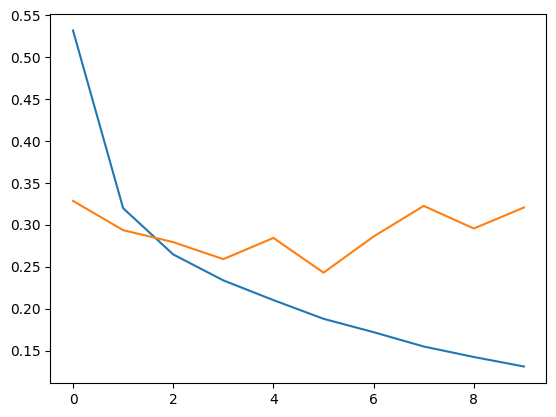

In [21]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

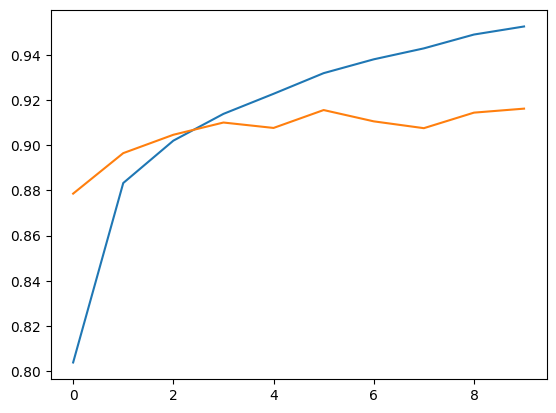

In [22]:
plt.plot(hy.history['acc'])
plt.plot(hy.history['val_acc'])

In [23]:
tr_scs = m.evaluate(e_tr_x, e_tr_y)
val_scs = m.evaluate(e_val_x, e_val_y)
tt_scs = m.evaluate(e_tt_x, e_tt_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - acc: 0.9642 - loss: 0.1008
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9175 - loss: 0.2888
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9134 - loss: 0.3420


In [24]:
tr_scs

[0.13978809118270874, 0.9558125138282776]

In [25]:
all_acc=abs(tr_scs[1]-val_scs[1])+abs(tr_scs[1]-tt_scs[1])+abs(tt_scs[1]-val_scs[1])
all_acc

0.0838249921798706

In [26]:
all_loss=abs(tr_scs[0]-val_scs[0])+abs(tr_scs[0]-tt_scs[0])+abs(tt_scs[0]-val_scs[0])
all_loss

0.3755282759666443

In [27]:
np.abs([1, -2, 3])

array([1, 2, 3])

In [28]:
py=m.predict(e_tr_x)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [29]:
print(classification_report(np.argmax(py, axis=1),np.argmax(ty, axis=1)))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92      5233
           1       1.00      1.00      1.00      4796
           2       0.94      0.92      0.93      4910
           3       0.98      0.95      0.96      4930
           4       0.90      0.96      0.93      4476
           5       0.99      1.00      0.99      4807
           6       0.83      0.91      0.87      4385
           7       0.99      0.97      0.98      4918
           8       1.00      0.99      1.00      4807
           9       0.97      0.99      0.98      4738

    accuracy                           0.96     48000
   macro avg       0.96      0.96      0.96     48000
weighted avg       0.96      0.96      0.96     48000



In [30]:
# 완성된 모델로 예측을 위한 준비
l_m = load_model('best_m.keras')
l_m

<Sequential name=sequential, built=True>

In [31]:
m.evaluate(e_tr_x, e_tr_y)
l_m.evaluate(e_tr_x, e_tr_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.9642 - loss: 0.1008
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.9465 - loss: 0.1414


[0.1585812121629715, 0.9413750171661377]

In [32]:
m.evaluate(e_tt_x, e_tt_y)
l_m.evaluate(e_tt_x, e_tt_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9134 - loss: 0.3420
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9117 - loss: 0.2736


[0.26491764187812805, 0.9121000170707703]

In [33]:
m.evaluate(e_val_x, e_val_y)
l_m.evaluate(e_val_x, e_val_y)

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9175 - loss: 0.2888
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9164 - loss: 0.2430


[0.24192169308662415, 0.9164166450500488]

In [34]:
tr_scs = l_m.evaluate(e_tr_x, e_tr_y)
val_scs = l_m.evaluate(e_val_x, e_val_y)
tt_scs = l_m.evaluate(e_tt_x, e_tt_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - acc: 0.9465 - loss: 0.1414
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9164 - loss: 0.2430
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9117 - loss: 0.2736


In [35]:
all_acc_l=abs(tr_scs[1]-val_scs[1])+abs(tr_scs[1]-tt_scs[1])+abs(tt_scs[1]-val_scs[1])
all_acc_l

0.05855000019073486

In [36]:
all_loss_l=abs(tr_scs[0]-val_scs[0])+abs(tr_scs[0]-tt_scs[0])+abs(tt_scs[0]-val_scs[0])
all_loss_l

0.2126728594303131

In [37]:
# 사용
# 전처리기(함수)
def 전처리기(이미지):
    전처리된_이미지 = 이미지 / 255.0
    return np.array([전처리된_이미지])
완성된_모델 = l_m

# 후처리기(함수)
def 후처리기(모델의_출력):
    import numpy as np
    np.array(['티셔츠', '상의', '바지', '풀오버', '드레스', '코트', '샌들', '셔츠', '스니커즈', '가방'])
    디코딩된_결과 = 정답[np.argmax(모델의_출력)]
    return 디코딩된_결과

In [38]:
def 완성된_예측기(입력_이미지):
    전처리된_이미지 = 전처리기(입력_이미지)
    모델의_출력 = 완성된_모델.predict(전처리된_이미지)
    디코딩된_결과 = 후처리기(모델의_출력)
    return 디코딩된_결과

# 완성된 모델로 이미지 예측기를 만들어라!!!

In [39]:
# CNN model
m = Sequential()
m.add(Input(shape=e_tr_x.shape[1:])) # 28, 28, 1
m.add(Conv2D(32, 3, 1, padding='same', activation='relu')) # 28, 28, 32
m.add(MaxPooling2D(2)) # 14, 14, 32
m.add(Conv2D(64, 3, 1, padding='same', activation='relu')) # 14, 14, 64
m.add(MaxPooling2D(2)) # 7, 7, 64
m.add(Conv2D(128, 3, 1, padding='same', activation='relu')) # 7, 7, 128
m.add(MaxPooling2D(2)) # 3, 3, 128
m.add(Conv2D(256, 3, 1, padding='same', activation='relu')) # 3, 3, 256
m.add(MaxPooling2D(2)) # 1, 1, 256 <- 여기까진 이미지로 남아있다
m.add(Flatten()) # 여기서 벡터로 변환

m.add(Dense(100, activation='relu'))
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,550 (1.58 MB)

 Trainable params: 414,550 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
print(m.layers[0].weights[0])
print(m.layers[0].weights[1])

<Variable path=sequential_1/conv2d_4/kernel, shape=(3, 3, 1, 32), dtype=float32, value=[[[[-0.05371255  0.12052278 -0.03099065 -0.10204655 -0.04529877
     0.08790313  0.02125791 -0.00115108  0.11964189 -0.00891776
     0.07126841 -0.11043356  0.13341539  0.13370208 -0.10377406
     0.01510362  0.0385008  -0.13290352  0.04423091  0.06369293
     0.04099447 -0.04270327  0.13228096  0.12438644  0.08558075
     0.0642197   0.0644992  -0.02663427  0.0253257  -0.07414581
     0.04000933  0.01394451]]

  [[ 0.03698973 -0.0605476   0.07944952 -0.10090201 -0.12287008
     0.1158881  -0.13590735 -0.07881393 -0.08575121 -0.04637615
    -0.0941019   0.04903498 -0.05976392  0.11464699 -0.02154987
    -0.12656644  0.12755792 -0.12044351  0.0402582   0.12622528
    -0.01816097 -0.01932155  0.05254345  0.10702087  0.10571252
     0.05179274  0.10139178  0.02416424  0.01135053  0.03409974
     0.01498692  0.008902  ]]

  [[ 0.09298399  0.11436231  0.07294443 -0.06733381  0.13031761
     0.04424098 -0.

In [41]:
from keras.applications import VGG16,vgg16

In [42]:
VGG16

<function keras.src.applications.vgg16.VGG16(include_top=True, weights='imagenet', input_tensor=None, input_shape=None, pooling=None, classes=1000, classifier_activation='softmax', name='vgg16')>

In [43]:
vgg16

<module 'keras.applications.vgg16' from '/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/keras/applications/vgg16/__init__.py'>

In [44]:
m=VGG16()
m

<Functional name=vgg16, built=True>

In [45]:
# VGG16 의 내부 파라미터

# include_top: bool = True,
#           weights: str = "imagenet",
#           input_tensor: Any = None,
#           input_shape: Any = None,
#           pooling: Any = None,
#           classes: int = 1000,
#           classifier_activation: str = "softmax",
#           name: str = "vgg16"

In [46]:
m.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
from keras.datasets import cifar10
(x,y),(tt_x,tt_y) = cifar10.load_data()

In [48]:
tr_x, val_x, tr_y, val_y = train_test_split(x, y, test_size=0.2)

In [49]:
tr_x.shape, tt_x.shape, val_x.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (10000, 32, 32, 3))

In [50]:
tr_x = tr_x.reshape(-1,32, 32, 3)

In [51]:
e_tr_y = to_categorical(tr_y)
e_tr_y.shape

(40000, 10)

In [52]:
m = VGG16(include_top=False, input_shape=(32, 32, 3), classes=10)

In [53]:
m.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
vgg_16 = m

In [55]:
m = Sequential()
m.add(Input(shape=(32, 32, 3)))
m.add(vgg_16)
m.add(Flatten())
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,818 (56.15 MB)

 Trainable params: 14,719,818 (56.15 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
m.predict(tr_x)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step


array([[7.4426012e-13, 4.2373204e-16, 3.3819056e-26, ..., 6.2779767e-11,
        1.3504854e-16, 1.5275722e-05],
       [6.8741214e-11, 5.9813357e-07, 3.1241682e-01, ..., 3.9599244e-12,
        6.6131033e-04, 2.8181770e-03],
       [9.9999809e-01, 9.5804204e-08, 1.1172888e-18, ..., 1.0141760e-11,
        9.2961742e-11, 1.8503157e-06],
       ...,
       [9.9785429e-01, 7.9823886e-19, 1.6837157e-08, ..., 2.1448696e-03,
        2.4069991e-20, 9.0936815e-12],
       [2.8705030e-13, 2.1635346e-05, 1.6670422e-14, ..., 3.0878514e-10,
        5.6634097e-13, 9.9963295e-01],
       [2.9123404e-20, 2.8237708e-09, 9.9999750e-01, ..., 1.3027255e-12,
        6.3253242e-07, 3.2856340e-07]], dtype=float32)

In [57]:
for i in vgg_16.layers:
    print(i.trainable)

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [58]:
vgg_16.layers[1].trainable = False

In [59]:
vgg_16.layers[1].trainable

False

In [60]:
for i in vgg_16.layers:
    print(i.trainable)

True
False
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [61]:
vgg16_1 = VGG16(include_top=False, input_shape=(32, 32, 3))

In [62]:
m = Sequential()
m.add(Input(shape=(32, 32, 3)))
m.add(vgg16_1)
m.add(Flatten())
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,818 (56.15 MB)

 Trainable params: 14,719,818 (56.15 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
m.layers[0].trainable = False

In [64]:
for i in m.layers:
    print(i.trainable)

False
True
True


In [65]:
for i in vgg16_1.layers:
    print(i.trainable)

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


In [66]:
m.compile(loss = 'sparse_categorical_crossentropy',  metrics = ['acc'])

In [67]:
tr_x.shape, tt_x.shape, val_x.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (10000, 32, 32, 3))

In [68]:
m.fit(tr_x, tr_y, epochs=10)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - acc: 0.3725 - loss: 9.5316
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - acc: 0.5344 - loss: 2.6720
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.5436 - loss: 2.1401
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.5469 - loss: 2.0536
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.5534 - loss: 2.0032
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.5482 - loss: 1.9968
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.5514 - loss: 2.0149
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.5503 - loss: 2.0373
Epoch 9/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - acc: 0.5523 - loss: 2.0151
Epoch 10/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - acc: 0.5502 - loss: 2.0209


In [69]:
vgg16_2 = VGG16(include_top=False, input_shape=(32, 32, 3))

In [75]:
m = Sequential()
m.add(Input(shape=(32, 32, 3)))
m.add(vgg16_2)
m.add(Flatten())
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,719,818 (56.15 MB)

 Trainable params: 14,719,818 (56.15 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
from keras.optimizers import Adam
adam = Adam(learning_rate=0.00001)

In [77]:
# Adam(
#     learning_rate: float = 0.001,
#     beta_1: float = 0.9,
#     beta_2: float = 0.999,
#     epsilon: float = 1e-7,
#     amsgrad: bool = False,
#     weight_decay: Any | None = None,
#     clipnorm: Any | None = None,
#     clipvalue: Any | None = None,
#     global_clipnorm: Any | None = None,
#     use_ema: bool = False,
#     ema_momentum: float = 0.99,
#     ema_overwrite_frequency: Any | None = None,
#     loss_scale_factor: Any | None = None,
#     gradient_accumulation_steps: Any | None = None,
#     name: str = "adam",
#     **kwargs: Any
# )

In [79]:
m.compile(optimizer=adam, loss = 'sparse_categorical_crossentropy',  metrics = ['acc'])
m.fit(tr_x, tr_y, epochs=10)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - acc: 0.5088 - loss: 1.4253
Epoch 2/10
 349/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - acc: 0.7312 - loss: 0.7917

KeyboardInterrupt: 

In [84]:
all_ck = VGG16(include_top=False, input_shape=(32, 32, 3))
all_ck.trainable = False
print("전부 번경")
for i in all_ck.layers:
    print(i.trainable)
m = Sequential()
n = 0
for i in all_ck.layers:
    if n > 14:
        i.trainable = True
    m.add(i)    
    n += 1
print("일부 개방 번경")
for i in m.layers:
    print(i.trainable)
m.summary()

전부 번경
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
일부 개방 번경
False
False
False
False
False
False
False
False
False
False
False
False
False
False
True
True
True
True


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
[i for i,j in enumerate(range(10)) if i>5] # 이 컴프리헨션은 파이썬 언어 기반으로 동작될 때만 사용가능

[6, 7, 8, 9]

In [86]:
(_,_),(X,y) = fashion_mnist.load_data()

In [87]:
X = X.reshape(-1, 28, 28, 1)

In [89]:
X

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [90]:
X,y

(array([[[[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         ...,
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]]],
 
 
        [[[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         [[0],
          [0],
          [0],
          ...,
          [0],
          [0],
          [0]],
 
         

In [91]:
X.shape, y.shape

((10000, 28, 28, 1), (10000,))

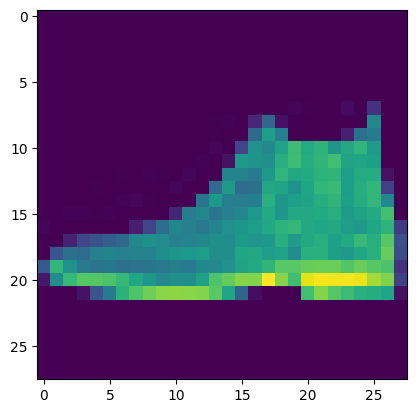

In [92]:
plt.imshow(X[0])

In [94]:
m = Sequential()
m.add(Input(shape=(28, 28, 1)))
m.add(Conv2D(3, 3, padding='same'))
m.add(MaxPooling2D(2))
m.add(Conv2D(6, 3, padding='same'))
m.add(MaxPooling2D(2))
m.add(Flatten())
m.add(Dense(10, activation='softmax'))

m.compile(loss='sparse_categorical_crossentropy', metrics=['acc'])

m.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 3)      │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 6)      │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 6)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 294)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,148 (12.30 KB)

 Trainable params: 3,148 (12.30 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
m.layers[0].weights[0] # weights

<Variable path=sequential_11/conv2d_10/kernel, shape=(3, 3, 1, 3), dtype=float32, value=[[[[ 0.21491325  0.13038069  0.2948882 ]]

  [[-0.3180165   0.34256208 -0.1742179 ]]

  [[ 0.34350282 -0.15139094 -0.20004791]]]


 [[[-0.15586245  0.34081453  0.33936214]]

  [[ 0.02550599 -0.35728228  0.22321504]]

  [[ 0.3459897   0.05427158 -0.00126436]]]


 [[[ 0.18595386  0.36608344 -0.0772391 ]]

  [[ 0.16623366  0.09216517 -0.35438505]]

  [[ 0.2416907  -0.09590423  0.03973445]]]]>

In [ ]:
(28, 28, 1)(3, 3, 1, 3) # weights의 형태

In [99]:
m.layers[2].weights[0] # weights

<Variable path=sequential_11/conv2d_11/kernel, shape=(3, 3, 3, 6), dtype=float32, value=[[[[-0.19126394 -0.26245362 -0.02051392  0.11503968 -0.07157591
    -0.19355142]
   [-0.04558942  0.07118163 -0.22144155 -0.1342686   0.11814308
    -0.06855154]
   [ 0.2487334  -0.24781063  0.07134432  0.08886027  0.25929648
    -0.1670998 ]]

  [[-0.18998003 -0.04020087 -0.15184218 -0.00357553 -0.16594926
    -0.1392613 ]
   [ 0.07550502 -0.01130819  0.09096372 -0.05399013  0.25670046
    -0.12610136]
   [-0.2610179  -0.19549517  0.24415153 -0.16800618  0.06848186
     0.13245311]]

  [[-0.0307626   0.16007689 -0.13120887 -0.14352603  0.10703865
     0.12706894]
   [ 0.2579286   0.12773293  0.2487399  -0.07604223 -0.0411094
     0.15343696]
   [ 0.05701837  0.04504058 -0.03613764  0.25297976  0.09512585
    -0.07497254]]]


 [[[ 0.10622913 -0.14009371  0.10346824  0.01866004  0.12932864
     0.07856956]
   [-0.08207026  0.21157539 -0.05693759 -0.14586361 -0.03313482
     0.10632181]
   [ 0.0063198

In [ ]:
(14, 14, 3)(3, 3, 3, 6) # weights의 형태 -> (14, 14, 6)

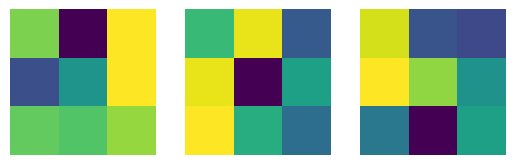

In [108]:
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(m.layers[0].weights[0].numpy()[:,:,:,i])
    plt.axis('off')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26234487..0.2579286].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26268256..0.25468582].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26328477..0.26993293].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2671206..0.25897843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21614873..0.26996017].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22427839..0.25727504].


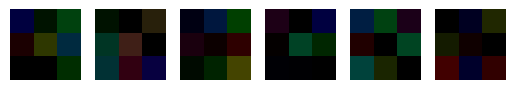

In [109]:
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(m.layers[2].weights[0].numpy()[:,:,:,i])
    plt.axis('off')
plt.show()

In [ ]:
m.fit(X, y, epochs=10, verbose=2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.5298 - loss: 17.2576
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.7396 - loss: 2.6146
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.7834 - loss: 1.2096
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8012 - loss: 0.8122
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8201 - loss: 0.5718
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8382 - loss: 0.4755
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8536 - loss: 0.4244
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8627 - loss: 0.3902
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.8695 - loss: 0.3784
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8744 - loss: 0.3563


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19825545..0.14905526].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24904688..0.17325284].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27894762..0.17251858].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15177034..0.20300882].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16172548..0.1761688].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16771759..0.15328851].


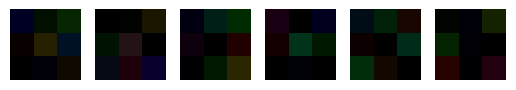

In [111]:
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(m.layers[2].weights[0].numpy()[:,:,:,i])
    plt.axis('off')
plt.show()

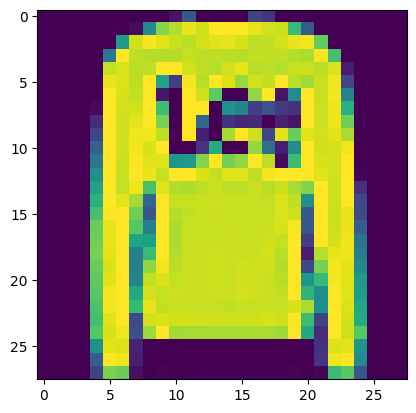

In [140]:
plt.imshow(X[1])

In [113]:
m.layers

[<Conv2D name=conv2d_10, built=True>,
 <MaxPooling2D name=max_pooling2d_10, built=True>,
 <Conv2D name=conv2d_11, built=True>,
 <MaxPooling2D name=max_pooling2d_11, built=True>,
 <Flatten name=flatten_7, built=True>,
 <Dense name=dense_9, built=True>]

In [114]:
from keras.models import Model

In [141]:
input = Input(shape=(28, 28, 1)) # 입력층 정의 tensor
out = m.layers[0](input)

In [142]:
ck_m1 = Model(input, out)

In [ ]:
m.inputs

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1109>]

In [121]:
m.outputs

[<KerasTensor shape=(None, 10), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1130>]

In [143]:
input = Input(shape=(28, 28, 1))
x=m.layers[0](input)
x=m.layers[1](x)
out = m.layers[2](x)

In [144]:
ck_m2 = Model(input, out)


In [148]:
out_im1 = ck_m1.predict(X[1:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [149]:
ck_1 = out_im1.reshape(28,28,3)

In [147]:
ck_1.shape

(28, 28, 3)

In [151]:
out_im2 = ck_m2.predict(X[1:2])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [152]:
ck_2 = out_im2.reshape(14, 14, 6)

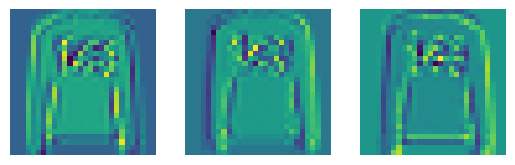

In [150]:
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(ck_1[:,:,i])
    plt.axis('off')
plt.show()

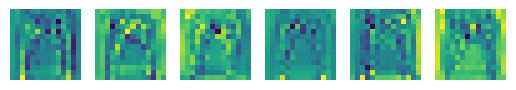

In [153]:
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(ck_2[:,:,i])
    plt.axis('off')
plt.show()

In [154]:
m.evaluate(X,y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8823 - loss: 0.3357


[0.3290562629699707, 0.8849999904632568]

In [155]:
py = np.argmax(m.predict(X), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [156]:
py

array([9, 2, 1, ..., 8, 1, 5])

In [158]:
ty = y

In [160]:
print(classification_report(ty, py))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1000
           1       0.98      0.98      0.98      1000
           2       0.82      0.81      0.81      1000
           3       0.85      0.93      0.89      1000
           4       0.81      0.77      0.79      1000
           5       0.99      0.94      0.96      1000
           6       0.69      0.71      0.70      1000
           7       0.95      0.96      0.96      1000
           8       0.98      0.95      0.97      1000
           9       0.94      0.99      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
학습이_잘된_class = [1, 8, 5, 9, 7]
학습이_안된_class = [6, 2]

In [166]:
# 잘된
x_1 = X[y==1]
x_8 = X[y==8]
x_5 = X[y==5]
x_9 = X[y==9]
x_7 = X[y==7]

In [172]:
# 안된
x_6 = X[y==6]
x_4 = X[y==4]

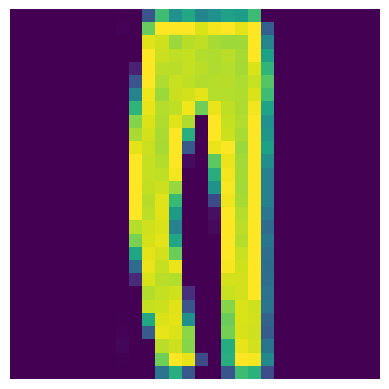

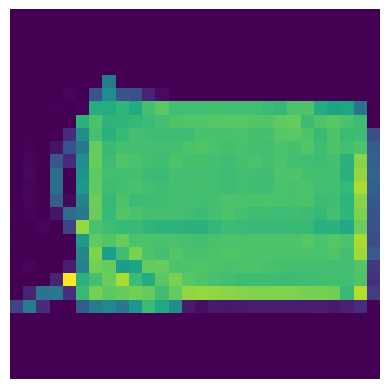

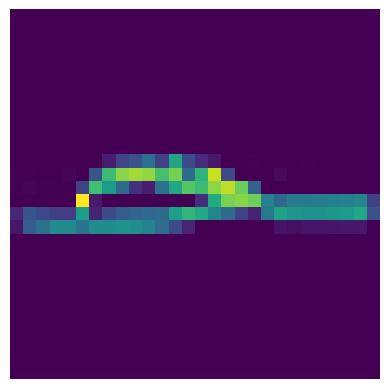

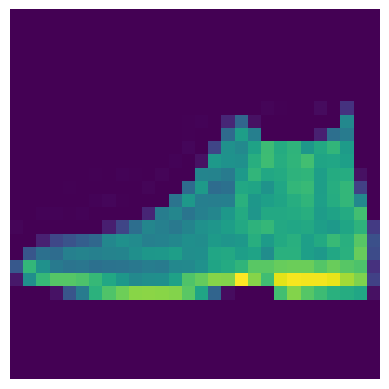

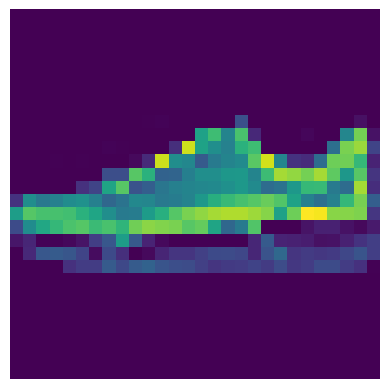

In [173]:
for i in [x_1, x_8, x_5, x_9, x_7]:
    plt.imshow(i[0])
    plt.axis('off')
    plt.show()

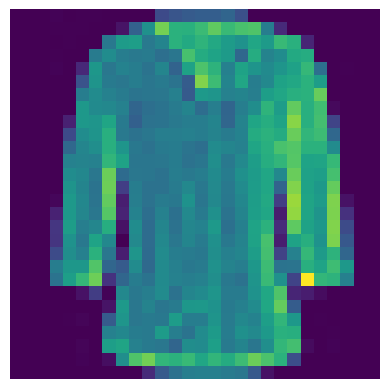

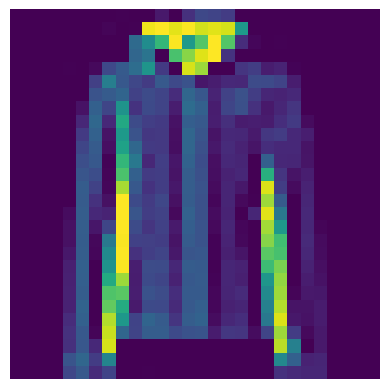

In [174]:
for i in [x_6, x_4]:
    plt.imshow(i[0])
    plt.axis('off')
    plt.show()

In [177]:
import gdown
gdown.download(id='18uC7WTuEXKJDDxbj-Jq6EjzpFrgE7IAd', output='dogs-vs-cats.zip')

Downloading...
From (original): https://drive.google.com/uc?id=18uC7WTuEXKJDDxbj-Jq6EjzpFrgE7IAd
From (redirected): https://drive.google.com/uc?id=18uC7WTuEXKJDDxbj-Jq6EjzpFrgE7IAd&confirm=t&uuid=f4c446d2-de5a-4d45-8725-e2b40dc49859
To: /Users/ihanjo/Library/CloudStorage/GoogleDrive-ihann5726@gmail.com/내 드라이브/인공지능 사관학교/Coding/8월/8-18/dogs-vs-cats.zip
100%|██████████| 852M/852M [00:26<00:00, 31.6MB/s] 


'dogs-vs-cats.zip'

In [178]:
import os
import shutil
import pathlib

In [206]:
old_dir = pathlib.Path('dogs-vs-cats/train')

In [207]:
old_dir

PosixPath('dogs-vs-cats/train')

In [208]:
new_dir = pathlib.Path('dogs-vs-cats_data')

In [209]:
def make_subset(sub_n, s_idx, e_idx):
    for i in ['cat', 'dog']:
        dir = new_dir/sub_n/i
        os.makedirs(dir)
        f_ns = [ f'{i}.{n}.jpg' for n in range(s_idx, e_idx)]
        for f_n in f_ns:
            shutil.copyfile(src=old_dir/f_n, dst=dir/f_n)

In [210]:
make_subset('tr_data', 0, 1000)

In [212]:
make_subset('tt_data', 0, 1000)

In [213]:
from keras.utils import image_dataset_from_directory
tr_ds = image_dataset_from_directory(new_dir/'tr_data', batch_size=32, image_size=(180, 180))

Found 2000 files belonging to 2 classes.


In [214]:
tr_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>